In [ ]:
%%capture
!wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

In [ ]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [ ]:
names = open('names.txt').read().splitlines()

# tokenizer
vocab = sorted(set(''.join(names) + '.'))
vocab_size = len(vocab)
stoi = {v:k for k, v in enumerate(vocab)}
itos = {v:k for k, v in stoi.items()}

def decode(seq: list[int]) -> str:
    return ''.join([itos[i] for i in seq])

def encode(name: str) -> list[int]:
    return [stoi[s] for s in name]

In [ ]:
from torch.utils.data import Dataset, TensorDataset, DataLoader

# class NamesDataset(Dataset):
#     def __init__(self, X, Y):
#         self.X = X
#         self.Y = Y

#     def __getitem__(self, idx):
#         return self.X[idx], self.Y[idx]

#     def __len__(self):
#         return self.X.shape[0]

block_size = 8

X = []
Y = []

for name in names:
    context = [0] * block_size
    for ch in name + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(f"{context} -> {ix}")
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

train_size = int(.8 * X.shape[0])
Xtr, Xts = X[:train_size], X[train_size:]
Ytr, Yts = Y[:train_size], Y[train_size:]

Dtr = TensorDataset(Xtr, Ytr)
Dts = TensorDataset(Xts, Yts)

In [ ]:
DLtr = DataLoader(Dtr, batch_size=32, shuffle=True, drop_last=True)
DLts = DataLoader(Dts, batch_size=32, shuffle=False, drop_last=False)

In [ ]:
class Linear(nn.Module):
    def __init__(self, in_features, out_features, bias=None):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(in_features, out_features))
        self.bias = nn.Parameter(torch.randn(out_features))

    def forward(self, x):
        return x @ self.weight + self.bias

class LinWithTanh(nn.Module):
    def __init__(self, in_features, out_features, bias=False, drop_rate=0):
        super().__init__()
        self.lin = nn.Linear(in_features, out_features, bias=bias)
        self.dropout = nn.Dropout(p=drop_rate)
        self.tanh = nn.Tanh()

    def forward(self, x):
        return self.tanh(self.lin(x))


class NameGenerator(nn.Module):
    def __init__(self, vocab_size, n_embd, block_size, n_hidden):
        super().__init__()
        self.E = nn.Embedding(vocab_size, n_embd)

        self.layer1 = LinWithTanh(block_size * n_embd, n_hidden)
        self.layers = nn.Sequential(
            *[LinWithTanh(n_hidden, n_hidden) for _ in range(10)]
        )

        self.out = Linear(n_hidden, vocab_size)
        self.apply(self._initialize)


    def _initialize(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight)
            # print('xavier initialization')

    def forward(self, x):
        # x: (B, T)
        xemb = self.E(x) # x shape: (B, T, C) or (batch_size, block_size, n_embd)
        # print(f"xemb shape: {xemb.shape}")
        B, T, C = xemb.shape
        x = xemb.view(B, T * C) # (B, T * C) or (batch_size, block_size * n_embd)
        x = self.layer1(x)
        x = self.layers(x)

        logits = self.out(x)
        return logits

n_embd = 32
model = NameGenerator(vocab_size, n_embd, block_size=3, n_hidden=150).to(device)
# model2 = NameGenerator(vocab_size, n_embd=32, block_size=3, n_hidden=150).to(device)
optimizer = torch.optim.Adam(model.parameters())
# optimizer2 = torch.optim.Adam(model2.parameters())

In [ ]:
n_embd = 8
block_size = 3

E = torch.randn(vocab_size, n_embd, requires_grad=True)
W1 = torch.randn(block_size * n_embd, 100, requires_grad=True)
b1 = torch.randn(100, requires_grad=True)

W2 = torch.randn(100, vocab_size, requires_grad=True)
b2 = torch.randn(vocab_size, requires_grad=True)


scale = torch.ones(100, requires_grad=True)
shift = torch.zeros(100, requires_grad=True)

parameters = [E, W1, b1, W2, b2, scale, shift]

print(scale)
print(shift)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], requires_grad=True)
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.], requires_grad=True)


In [ ]:
class BatchNorm1d(nn.Module):
    def __init__(self, dim, momentum=0.1):
        super().__init__()
        self.dim = dim
        self.momentum = momentum
        self.eps = 1e-6

        self.scale = nn.Parameter(torch.ones(dim))
        self.shift = nn.Parameter(torch.zeros(dim))

        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)


    def forward(self, x):
        if self.training:
            xmean = x.mean(dim=0, keepdim=True)
            xvar = x.var(dim=0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        x = (x - xmean) / (xvar + self.eps) **0.5

        x = self.scale * x + self.shift

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return x

bn = BatchNorm1d()

In [ ]:
bn.training

True

In [ ]:
bn.eval()

BatchNorm1d()

In [ ]:
bn.train()

BatchNorm1d()

In [ ]:
eps = 1e-6

for x, y in DLtr:
    x, y = x.to(device), y.to(device)

    x = E[x]
    B, T, C = x.shape
    x = x.view(B, T*C)
    x = x @ W1 + b1

    xmean = x.mean(dim=0, keepdim=True)
    xvar = x.var(dim=0, keepdim=True)

    x = (x - xmean) / (xvar + eps) **0.5

    x = scale * x + shift

    x = torch.tanh(x) # activation

    logits = x @ W2 + b2
    loss = F.cross_entropy(logits, y)

    for param in parameters:
        param.grad = None

    loss.backward()

    for param in parameters:
        param.data -= 0.0001 * param.grad

In [ ]:
xall = E[Xtr].view(-1, 24)

In [ ]:
xall_mean = xall.mean(dim=0, keepdim=True)

In [ ]:
xall_var = xall.var(dim=0, keepdim=True)

In [ ]:
# this is for evaluation
for x, y in DLts:
    x, y = x.to(device), y.to(device)

    x = E[x]
    B, T, C = x.shape
    x = x.view(B, T*C)
    x = x @ W1 + b1

    x = (x - xall_mean) / (xall_var + eps) **0.5

    x = scale * x + shift

    x = torch.tanh(x) # activation

    logits = x @ W2 + b2
    loss = F.cross_entropy(logits, y)


In [ ]:
x.shape

torch.Size([32, 100])

In [ ]:
print(scale)
print(shift)

tensor([0.9478, 0.9643, 0.9367, 0.9678, 0.9811, 0.9522, 0.9384, 0.9742, 0.9670,
        0.9532, 0.9706, 0.9562, 0.9800, 0.9826, 0.9863, 0.9658, 0.9681, 0.9492,
        0.9922, 1.0025, 0.9298, 0.9788, 0.9208, 0.9988, 0.9910, 1.0024, 0.9923,
        0.9813, 0.9541, 0.9778, 0.9696, 0.9841, 1.0018, 0.9743, 1.0055, 0.9962,
        0.9794, 0.9831, 0.9511, 0.9888, 0.9616, 1.0062, 0.9489, 0.9842, 0.9499,
        0.9456, 0.9423, 0.9211, 0.9797, 0.9758, 1.0150, 0.9626, 0.9277, 0.9695,
        0.9814, 0.9373, 0.9538, 0.9986, 0.9437, 0.9306, 0.9727, 1.0115, 0.9623,
        0.9543, 0.9915, 0.9929, 1.0001, 0.9857, 0.9892, 0.9461, 0.9569, 0.9692,
        0.9777, 1.0030, 0.9770, 0.9732, 0.9426, 0.9549, 0.9850, 0.9498, 0.9151,
        0.9520, 1.0137, 0.9540, 0.9550, 0.9767, 0.9469, 0.9879, 0.9410, 0.9132,
        0.9448, 0.9562, 0.9755, 0.9737, 0.9539, 0.9759, 1.0012, 0.9842, 0.9311,
        0.9627], requires_grad=True)
tensor([ 7.8110e-05, -6.0366e-02, -5.4275e-02, -1.5901e-01, -4.7818e-02,
         1

In [ ]:
x = torch.randn(200, 10000)
W = torch.randn(10000, 500) / (10000 ** 0.5)

print(f"{x.mean()=} \t {x.std()=}")
print(f"{W.mean()=} \t {W.std()=}")

c = (x @ W)
print(f"{c.mean()=} \t {c.std()=}")

x.mean()=tensor(0.0004) 	 x.std()=tensor(1.0001)
W.mean()=tensor(-1.1079e-06) 	 W.std()=tensor(0.0100)
c.mean()=tensor(0.0015) 	 c.std()=tensor(1.0000)


In [ ]:
x.shape

torch.Size([32, 24])

In [ ]:
x.mean(dim=0, keepdim=True).shape

torch.Size([1, 24])

In [ ]:
for x, y in DLtr:
    x, y = x.to(device), y.to(device)
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    optimizer.zero_grad()
    loss.backward()
    print(loss)
    optimizer.step()

Streaming output truncated to the last 5000 lines.
tensor(14.5722, grad_fn=<NllLossBackward0>)
tensor(17.4862, grad_fn=<NllLossBackward0>)
tensor(16.7565, grad_fn=<NllLossBackward0>)
tensor(18.5065, grad_fn=<NllLossBackward0>)
tensor(16.0028, grad_fn=<NllLossBackward0>)
tensor(15.3336, grad_fn=<NllLossBackward0>)
tensor(13.1203, grad_fn=<NllLossBackward0>)
tensor(13.8578, grad_fn=<NllLossBackward0>)
tensor(15.9384, grad_fn=<NllLossBackward0>)
tensor(14.7495, grad_fn=<NllLossBackward0>)
tensor(12.7354, grad_fn=<NllLossBackward0>)
tensor(13.7220, grad_fn=<NllLossBackward0>)
tensor(13.3364, grad_fn=<NllLossBackward0>)
tensor(16.8561, grad_fn=<NllLossBackward0>)
tensor(14.8309, grad_fn=<NllLossBackward0>)
tensor(17.9295, grad_fn=<NllLossBackward0>)
tensor(11.6105, grad_fn=<NllLossBackward0>)
tensor(16.3453, grad_fn=<NllLossBackward0>)
tensor(14.9891, grad_fn=<NllLossBackward0>)
tensor(17.7443, grad_fn=<NllLossBackward0>)
tensor(15.6435, grad_fn=<NllLossBackward0>)
tensor(14.9839, grad_fn=<

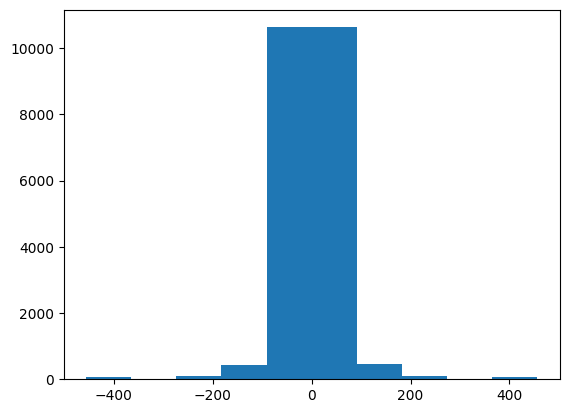

In [ ]:
plt.hist(model.layers[2].lin.weight.grad.view(-1).tolist());

In [ ]:
model.layer1.lin.weight.grad.max()

tensor(16319.3750)

In [ ]:
def plot_embedding():

    w = model.E.weight.cpu().detach().numpy()

    plt.figure(figsize=(8, 8))
    plt.scatter(w[:, 0], w[:, 1], s=200)

    for i in range(27):
        char = itos[i]
        plt.text(w[i][0], w[i][1], char, ha='center', va='center', color='white')
    plt.show()

In [ ]:
from IPython.display import clear_output

In [ ]:
@torch.no_grad()
def evaluate(model):
    model.eval()

    epoch_loss = 0.0
    for x, y in DLts:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        epoch_loss += loss.item()
    epoch_loss /= len(DLts)

    return epoch_loss

In [ ]:
def train(model, optimizer, n_epoch = 10):
    torch.manual_seed(42)
    lossi = []

    for epoch in range(n_epoch):
        model.train()
        epoch_loss = 0.0
        for x, y in DLtr:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y)

            # for param in model.parameters():
            #     param.grad = None
            optimizer.zero_grad()

            loss.backward()

            # for param in model.parameters():
            #     param.data -= 0.01 * param.grad
            optimizer.step()

            epoch_loss += loss.item()
            lossi.append(loss.item())
        epoch_loss /= len(DLtr)
        eval_loss = evaluate(model)
        print(f"Epoch {epoch+1} | Train Loss: {epoch_loss:.3f} | Eval Loss: {eval_loss:.3f}")

    return lossi
        # plot_embedding()
        # clear_output(wait=True)

In [ ]:
lossi = train(model, optimizer)

Epoch 1 | Train Loss: 2.386 | Eval Loss: 2.562
Epoch 2 | Train Loss: 2.348 | Eval Loss: 2.538
Epoch 3 | Train Loss: 2.322 | Eval Loss: 2.525
Epoch 4 | Train Loss: 2.302 | Eval Loss: 2.507
Epoch 5 | Train Loss: 2.287 | Eval Loss: 2.505
Epoch 6 | Train Loss: 2.276 | Eval Loss: 2.511
Epoch 7 | Train Loss: 2.267 | Eval Loss: 2.498
Epoch 8 | Train Loss: 2.260 | Eval Loss: 2.490
Epoch 9 | Train Loss: 2.255 | Eval Loss: 2.497
Epoch 10 | Train Loss: 2.250 | Eval Loss: 2.491


In [ ]:
lossi = train(model2, optimizer2)

Epoch 1 | Train Loss: 2.242 | Eval Loss: 2.423
